#### Problem Statement
A retail company “ABC Private Limited” wants to understand the customer purchase behaviour (specifically, purchase amount) against various products of different categories. They have shared purchase summary of various customers for selected high volume products from last month. The data set also contains customer demographics (age, gender, marital status, city_type, stay_in_current_city), product details (product_id and product category) and Total purchase_amount from last month.

Now, they want to build a model to predict the purchase amount of customer against various products which will help them to create personalized offer for customers against different products.

### Black Friday Dataset EDA And Feature Engineering

#### Cleaning and preparing the data for model training


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df_train = pd.read_csv('./BlackFridayDataset/train.csv')
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [3]:
df_test = pd.read_csv('./BlackFridayDataset/test.csv')
df_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233599 entries, 0 to 233598
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     233599 non-null  int64  
 1   Product_ID                  233599 non-null  object 
 2   Gender                      233599 non-null  object 
 3   Age                         233599 non-null  object 
 4   Occupation                  233599 non-null  int64  
 5   City_Category               233599 non-null  object 
 6   Stay_In_Current_City_Years  233599 non-null  object 
 7   Marital_Status              233599 non-null  int64  
 8   Product_Category_1          233599 non-null  int64  
 9   Product_Category_2          161255 non-null  float64
 10  Product_Category_3          71037 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 19.6+ MB


In [4]:
df_train.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [121]:
df_train.shape

(550068, 12)

In [122]:
df_test.shape

(233599, 11)

In [6]:
df = df_train.merge(df_test, how='outer')
df.shape

(783667, 12)

In [152]:
df_test.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


In [153]:
df.info() # observation ---> NaN forces numbers to float (purchase column is missing in test set hence NaN)
# learning: When merging two dataframes, if one dataframe has missing values for certain columns, those missing values will be represented as NaN in the merged dataframe. This can lead to changes in data types, especially for numerical columns, which may be converted to float to accommodate the NaN values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 71.7+ MB


In [7]:
df.drop(columns=['User_ID'], inplace=True)
#learning: User_ID is not useful for analysis as it is just an identifier and does not provide any meaningful information about the users or their purchasing behavior. Cleaning such columns helps in reducing noise and improving the quality of the data for analysis.

In [127]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650.0
1,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645.0
2,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416.0
3,P00051442,F,0-17,10,A,2,0,8,17.0,NaN,9938.0
4,P00051842,F,0-17,10,A,2,0,4,8.0,NaN,2849.0


In [128]:
# learning: Changing categorical data into numerical data using mapping helps machine learning algorithms to better understand and process the data, as they typically work better with numerical inputs. Machine learning algorithms need numbers, but categorical numbers need correct representation.

# pd.get_dummies() creates binary columns for each category → prevents wrong assumptions about order.

# drop_first=True removes redundancy.
# If you have n categories, one-hot encoding creates n columns. But one of these columns is redundant, because knowing the values of n-1 columns automatically tells you the last one.

# Example:

# Color_Red	Color_Blue	Color_Green
# 1	0	0

# If Color_Red=1 and Color_Blue=0, you already know Color_Green=0.

# drop_first=True removes one column to avoid multicollinearity (important for linear models):



In [129]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

#### Categorical Variable Encoding Cheat Sheet

| Method                            | Best For                                         | How It Works                                                        | Pros                                                          | Cons                                                                              | Example                                                                                                                      |
| --------------------------------- | ------------------------------------------------ | ------------------------------------------------------------------- | ------------------------------------------------------------- | --------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| **`map()`**                       | **Binary categories only** (2 unique values)     | Replace each category with a number you choose                      | Simple, fast, no extra columns                                | Only works for 2 categories, errors for unseen values                             | `df['Gender'] = df['Gender'].map({'F':0, 'M':1})`                                                                            |
| **`pd.get_dummies()`**            | **Any number of categories** (especially >2)     | Creates **new binary columns** (one-hot encoding) for each category | Works for multiple categories, avoids wrong order assumptions | Can create many columns for high-cardinality features                             | `pd.get_dummies(df['Color'], drop_first=True)`                                                                               |
| **`LabelEncoder` (from sklearn)** | **Ordinal or categorical for tree-based models** | Converts each category to a **unique integer**                      | Works with many categories, sklearn-friendly                  | Implies order (not good for linear/logistic regression if categories are nominal) | `from sklearn.preprocessing import LabelEncoder` <br> `le = LabelEncoder()` <br> `df['City'] = le.fit_transform(df['City'])` |


In [130]:
# df['Gender'] = pd.get_dummies(df['Gender'], drop_first=1)
pd.get_dummies(df['Gender'], drop_first=1)


,M
0,False
1,False
2,False
3,False
4,False
...,...
783662,True
783663,True
783664,True
783665,True


In [131]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650.0
1,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645.0
2,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416.0
3,P00051442,F,0-17,10,A,2,0,8,17.0,NaN,9938.0
4,P00051842,F,0-17,10,A,2,0,4,8.0,NaN,2849.0


In [8]:
df['Gender'] = df['Gender'].map({'M':1, 'F':0})

In [133]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00000142,0,0-17,10,A,2,0,3,4.0,5.0,13650.0
1,P00004842,0,0-17,10,A,2,0,3,4.0,12.0,13645.0
2,P00025442,0,0-17,10,A,2,0,1,2.0,9.0,15416.0
3,P00051442,0,0-17,10,A,2,0,8,17.0,NaN,9938.0
4,P00051842,0,0-17,10,A,2,0,4,8.0,NaN,2849.0


In [9]:
df.rename(columns={'Gender':'M-1F-0'}, inplace=True)

In [157]:
# handling age
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [10]:
df['Age'] = df['Age'].map({'0-17':1, '18-25':2, '26-35':3, '36-45':4, '46-50':5, '51-55':6, '55+':7})
### learning: Here, we are converting the age ranges into ordinal numerical values. This mapping assigns a unique integer to each age range, preserving the order of the age groups. This approach is useful when the age ranges have a natural order, and it allows machine learning algorithms to understand the relative differences between the age groups. -> this is called Target Ordinal Encoding.

In [159]:
df['Age'].unique()

array([1, 7, 3, 5, 6, 4, 2])

In [160]:
df.City_Category.unique()

array(['A', 'C', 'B'], dtype=object)

In [11]:
 # learning: city category is nominal categorical data as there is no inherent order or ranking among the categories (A, B, C). Therefore, one-hot encoding is appropriate here to create binary columns for each category without implying any order.
df = pd.get_dummies(df, columns=['City_Category'], drop_first=True)


In [140]:
df.shape

(783667, 12)

In [141]:
df.head()

,Product_ID,M-1F-0,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,P00000142,0,1,10,2,0,3,4.0,5.0,13650.0,False,False
1,P00004842,0,1,10,2,0,3,4.0,12.0,13645.0,False,False
2,P00025442,0,1,10,2,0,1,2.0,9.0,15416.0,False,False
3,P00051442,0,1,10,2,0,8,17.0,NaN,9938.0,False,False
4,P00051842,0,1,10,2,0,4,8.0,NaN,2849.0,False,False


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   M-1F-0                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  object 
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          537685 non-null  float64
 8   Product_Category_3          237858 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  City_Category_B             783667 non-null  bool   
 11  City_Category_C             783667 non-null  bool   
dtypes: bool(2), float64(3), int64(5), object(2)
memory usage: 61.3+ MB


In [162]:
df.isnull().sum()

Product_ID                         0
M-1F-0                             0
Age                                0
Occupation                         0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
City_Category_B                    0
City_Category_C                    0
dtype: int64

In [163]:
### focus on handling null values next (product_category_2 and product_category_3, since purchase column is target variable and is missing in test set)
df[df['Product_Category_2'].notnull()].head()


,Product_ID,M-1F-0,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,P00000142,0,1,10,2,0,3,4.0,5.0,13650.0,False,False
1,P00004842,0,1,10,2,0,3,4.0,12.0,13645.0,False,False
2,P00025442,0,1,10,2,0,1,2.0,9.0,15416.0,False,False
3,P00051442,0,1,10,2,0,8,17.0,NaN,9938.0,False,False
4,P00051842,0,1,10,2,0,4,8.0,NaN,2849.0,False,False


#### Handling Missing Values in Categorical Columns

| **Method**                              | **Best When**                                                   | **Cons If**                              | **How**                                                               |
| --------------------------------------- | --------------------------------------------------------------- | ---------------------------------------- | --------------------------------------------------------------------- |
| **Create a new category (`'Unknown'`)** | Missing value itself carries meaning; you want to keep all rows | Too many `"Unknown"` values may dominate | `df['col'] = df['col'].fillna('Unknown')`                             |
| **Mode (most frequent value)**          | Very few missing values; data is stable                         | Can introduce bias; hides missingness    | `df['col'].fillna(df['col'].mode()[0])`                               |
| **Drop rows**                           | Missing values are extremely rare; dataset is large             | Data loss if missing is not random       | `df.dropna(subset=['col'])`                                           |
| **Group-based imputation**              | Another column strongly predicts the category                   | Fails if group has no mode               | `df.groupby('grp')['col'].transform(lambda x: x.fillna(x.mode()[0]))` |
| **Target-based imputation**             | High-cardinality features; advanced ML setup                    | High risk of data leakage & overfitting  | Use CV-based target encoding (train only)                             |


In [165]:
df.Product_Category_2.unique()

array([ 4.,  2., 17.,  8., nan,  5., 14., 15.,  3.,  6.,  9., 16., 13.,
       11., 18., 12., 10.,  7.])

In [166]:
df.Product_Category_2.value_counts()

Product_Category_2
8.0     91317
14.0    78834
2.0     70498
16.0    61687
15.0    54114
5.0     37165
4.0     36705
6.0     23575
11.0    20230
17.0    19104
13.0    15054
9.0      8177
12.0     7801
10.0     4420
3.0      4123
18.0     4027
7.0       854
Name: count, dtype: int64

In [12]:
### replacing null values with mode (most frequent value)
mode_pc2 = df['Product_Category_2'].mode()[0]
df['Product_Category_2'] = df['Product_Category_2'].fillna(mode_pc2)

In [13]:
df.Product_Category_2.isnull().sum()

np.int64(0)

In [14]:
df.Product_Category_3.unique()

array([ 5., 12.,  9., nan, 16.,  8.,  4., 17., 14., 15., 13.,  6., 18.,
       10., 11.,  3.])

In [15]:
df.Product_Category_3.isnull().sum()

np.int64(545809)

In [16]:
df.Product_Category_3.value_counts()

Product_Category_3
16.0    46469
15.0    39968
14.0    26283
17.0    23818
5.0     23799
8.0     17861
9.0     16532
12.0    13115
13.0     7849
6.0      6888
18.0     6621
4.0      2691
11.0     2585
10.0     2501
3.0       878
Name: count, dtype: int64

In [17]:
mode_pc3 = df['Product_Category_3'].mode()[0]
df['Product_Category_3'] = df['Product_Category_3'].fillna(mode_pc3)

In [18]:
df.Product_Category_3.isnull().sum()

np.int64(0)

In [175]:
df.shape

(783667, 12)

In [176]:
# handling stay in current city years
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [19]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+', '')

In [178]:
df.head()

,Product_ID,M-1F-0,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,P00000142,0,1,10,2,0,3,4.0,5.0,13650.0,False,False
1,P00004842,0,1,10,2,0,3,4.0,12.0,13645.0,False,False
2,P00025442,0,1,10,2,0,1,2.0,9.0,15416.0,False,False
3,P00051442,0,1,10,2,0,8,17.0,16.0,9938.0,False,False
4,P00051842,0,1,10,2,0,4,8.0,16.0,2849.0,False,False


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   M-1F-0                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  object 
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          783667 non-null  float64
 8   Product_Category_3          783667 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  City_Category_B             783667 non-null  bool   
 11  City_Category_C             783667 non-null  bool   
dtypes: bool(2), float64(3), int64(5), object(2)
memory usage: 61.3+ MB


In [20]:
# convert object to integer for 'Stay_In_Current_City_Years'
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype(int)

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   M-1F-0                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  int64  
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          783667 non-null  float64
 8   Product_Category_3          783667 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  City_Category_B             783667 non-null  bool   
 11  City_Category_C             783667 non-null  bool   
dtypes: bool(2), float64(3), int64(6), object(1)
memory usage: 61.3+ MB


In [21]:
df['City_Category_B'] = df['City_Category_B'].astype(int)
df['City_Category_C'] = df['City_Category_C'].astype(int)

In [183]:
df.head()

,Product_ID,M-1F-0,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,P00000142,0,1,10,2,0,3,4.0,5.0,13650.0,0,0
1,P00004842,0,1,10,2,0,3,4.0,12.0,13645.0,0,0
2,P00025442,0,1,10,2,0,1,2.0,9.0,15416.0,0,0
3,P00051442,0,1,10,2,0,8,17.0,16.0,9938.0,0,0
4,P00051842,0,1,10,2,0,4,8.0,16.0,2849.0,0,0


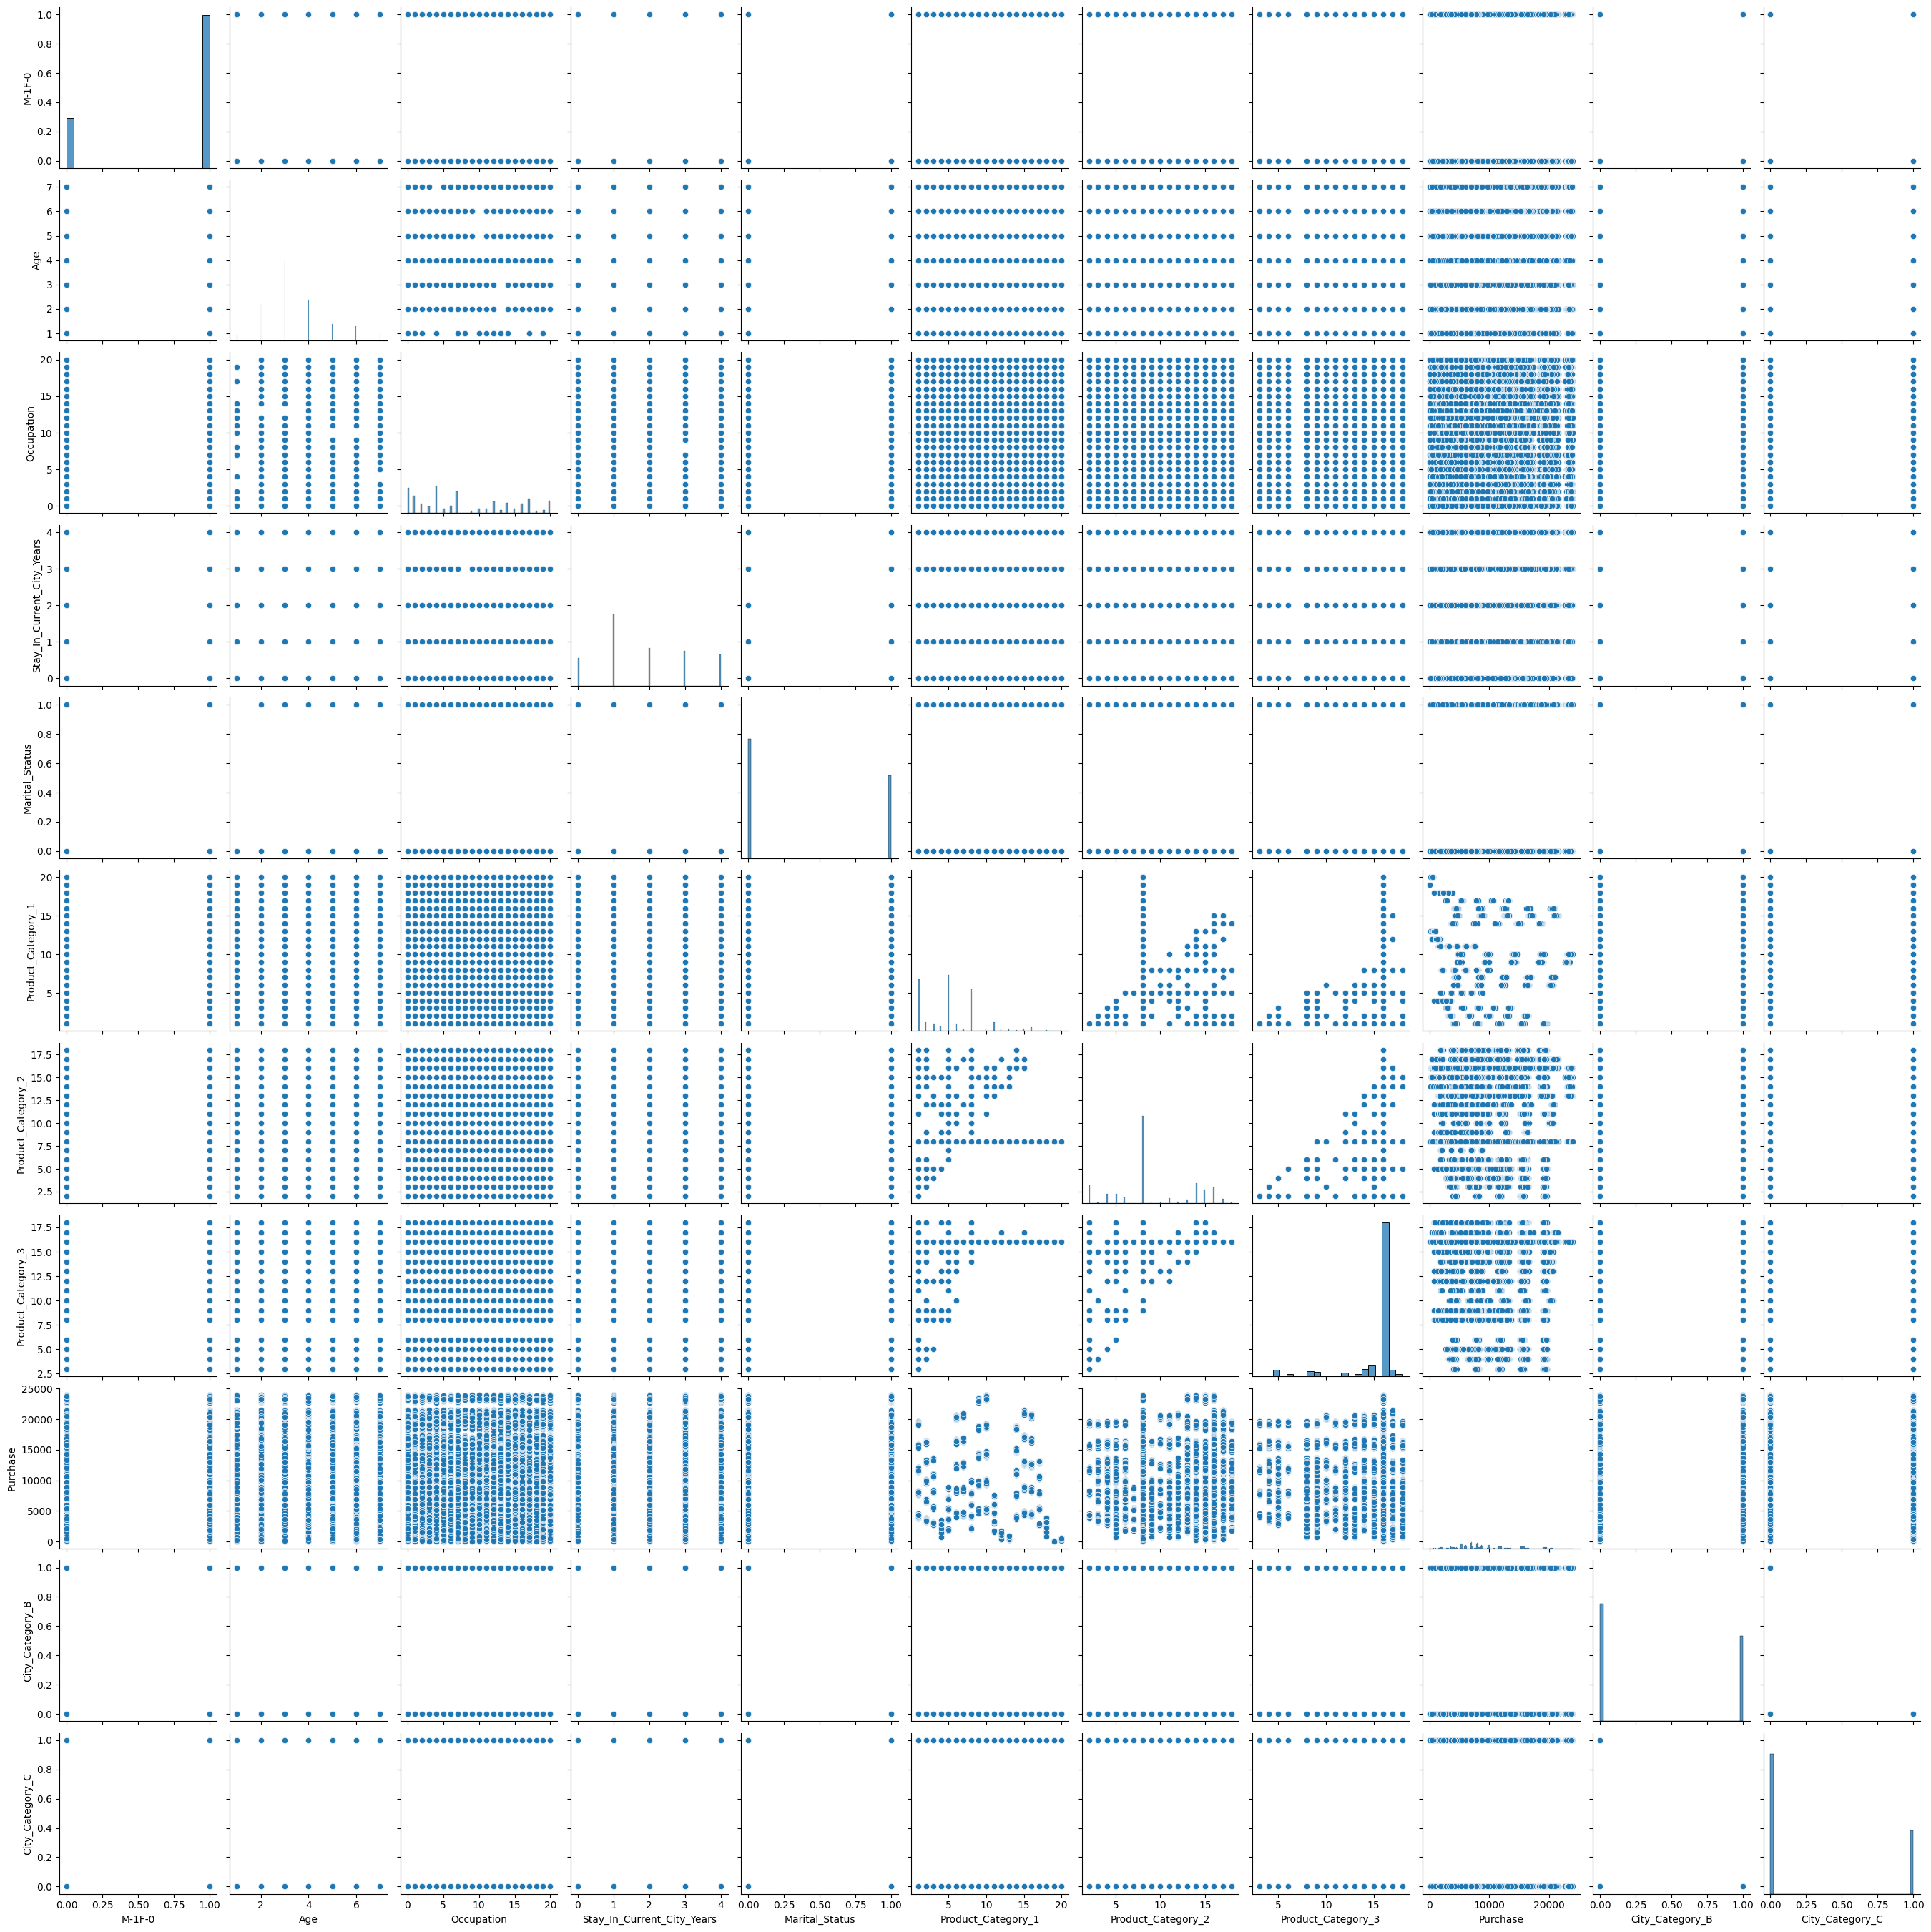

In [184]:
### Visualizations and Insights
sns.pairplot(df)


<Axes: xlabel='Age', ylabel='Purchase'>

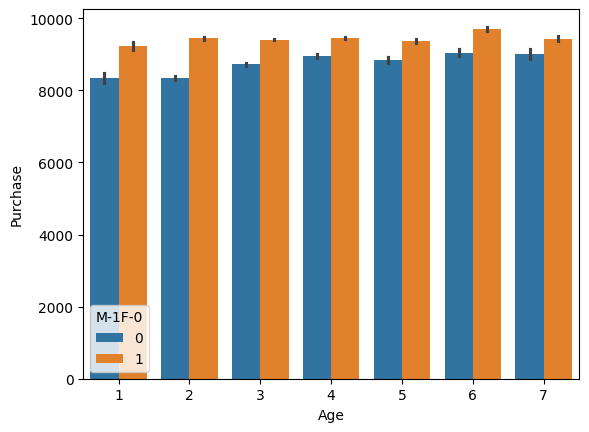

In [23]:
sns.barplot(df, x='Age', y='Purchase', hue='M-1F-0')

In [24]:
### observation: purchasing of men is high then women

<Axes: xlabel='Occupation', ylabel='Purchase'>

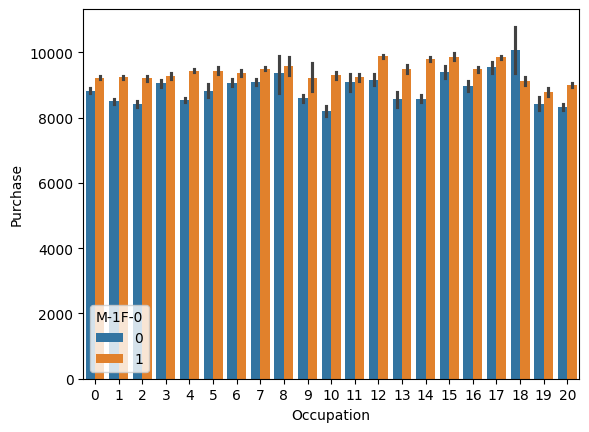

In [25]:
sns.barplot(df, x='Occupation', y='Purchase', hue='M-1F-0')

In [ ]:

df_test = df[df['Purchase'].isnull()]

In [27]:
df_train = df[~df['Purchase'].isnull()]

In [29]:
df_test

,Product_ID,M-1F-0,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
5,P00057542,0,1,10,2,0,3,4.0,5.0,NaN,0,0
7,P00058242,0,1,10,2,0,3,4.0,12.0,NaN,0,0
11,P00070942,0,1,10,2,0,3,5.0,16.0,NaN,0,0
17,P00110542,0,1,10,2,0,8,8.0,16.0,NaN,0,0
20,P00115542,0,1,10,2,0,8,8.0,16.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
783655,P00321842,1,3,6,2,0,8,8.0,16.0,NaN,1,0
783657,P00327242,1,3,6,2,0,5,8.0,16.0,NaN,1,0
783658,P00327342,1,3,6,2,0,16,8.0,16.0,NaN,1,0
783663,P00344242,1,3,6,2,0,8,10.0,16.0,NaN,1,0


In [ ]:
### Feature Scaling